# Introduction : Analyse du jeu de données MPG

Dans ce tutoriel, nous allons explorer en détail le jeu de données "mpg". Ce jeu de données, initialement publié par la bibliothèque StatLib de l'Université Carnegie Mellon et désormais disponible dans la bibliothèque Seaborn. L'objectif de ce tutoriel est d'explorer la relation entre la consommation de carburant (Miles Per Gallon, ou MPG) et diverses autres caractéristiques de ce jeu de données.

Le jeu de données "mpg" est particulièrement intéressant pour notre étude car il présente une combinaison de caractéristiques discrètes et continues. Il contient :

- 3 caractéristiques discrètes : Ces variables catégorielles nous permettront d'analyser des groupes ou des classifications au sein des données.
- 5 caractéristiques continues : Ces variables numériques nous permettront d'examiner des relations et des tendances quantitatives.

In [1]:
import seaborn as sns
# load a seaborn dataset
mpg_df = sns.load_dataset("mpg")
mpg_df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [1]:
import pandas as pd
import seaborn as sns
import plotly.express as px
import plotly.io as pio

# Affichage des graphiques en PNG (compatible GitHub)
pio.renderers.default = "png"

In [3]:
# Structure et types de données
# 3 caractéristiques discrètes : cylinders, origin, name
# 5 caractéristiques continues : mpg, displacement, horsepower, weight, acceleration
print(mpg_df.dtypes)
print(f"\nDimensions : {mpg_df.shape}")

mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model_year        int64
origin              str
name                str
dtype: object

Dimensions : (398, 9)


In [4]:
# Statistiques descriptives
mpg_df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


In [5]:
# Vérification des valeurs manquantes
print(mpg_df.isnull().sum())

# Suppression des lignes avec valeurs manquantes
mpg_df = mpg_df.dropna()
print(f"\nDimensions après nettoyage : {mpg_df.shape}")

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64

Dimensions après nettoyage : (392, 9)


Ce graphique montre la répartition des véhicules selon leur pays d'origine (USA, Europe, Japon). Il permet d'identifier quelle région est la plus représentée dans le dataset, ce qui peut introduire un biais dans l'analyse globale.

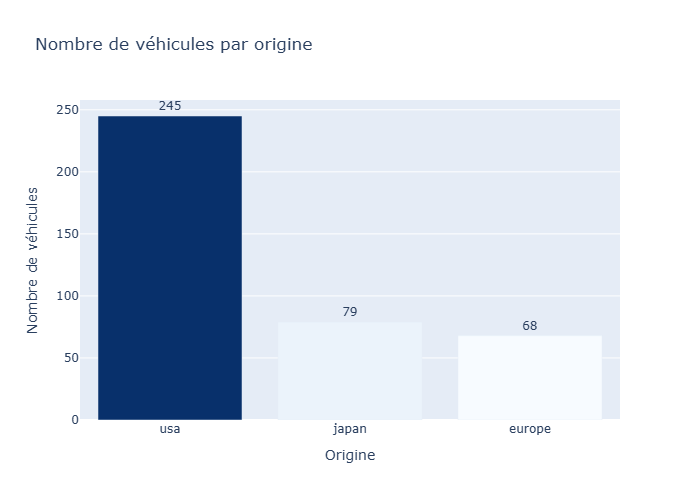

In [6]:
origin_counts = mpg_df['origin'].value_counts().reset_index()
origin_counts.columns = ['origin', 'count']

fig = px.bar(
    origin_counts,
    x='origin', y='count',
    title='Nombre de véhicules par origine',
    labels={'origin': 'Origine', 'count': 'Nombre de véhicules'},
    color='count',
    color_continuous_scale='Blues',
    text='count'
)
fig.update_traces(textposition='outside')
fig.update_layout(coloraxis_showscale=False)
fig.show()

Ce graphique illustre la distribution des véhicules selon leur nombre de cylindres. Le nombre de cylindres est une caractéristique technique importante qui influence directement la puissance et la consommation du véhicule. Les moteurs à 4 et 8 cylindres sont les plus répandus. Les 4 cylindres sont typiques des véhicules japonais et européens plus économiques, tandis que les 8 cylindres caractérisent les grosses cylindrées américaines.

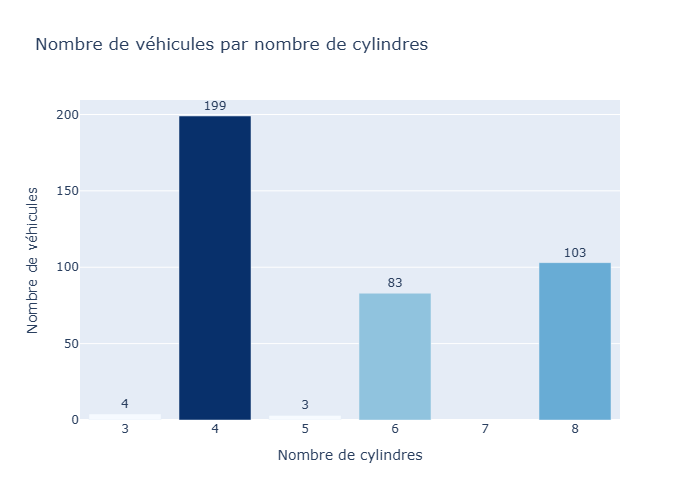

In [7]:
cyl_counts = mpg_df['cylinders'].value_counts().reset_index()
cyl_counts.columns = ['cylinders', 'count']
cyl_counts = cyl_counts.sort_values('cylinders')

fig = px.bar(
    cyl_counts,
    x='cylinders', y='count',
    title='Nombre de véhicules par nombre de cylindres',
    labels={'cylinders': 'Nombre de cylindres', 'count': 'Nombre de véhicules'},
    color='count',
    color_continuous_scale='Blues',
    text='count'
)
fig.update_traces(textposition='outside')
fig.update_layout(coloraxis_showscale=False)
fig.show()

Cet histogramme montre comment se répartissent les valeurs de consommation (MPG) sur l'ensemble du dataset. Il permet de comprendre si la distribution est symétrique, asymétrique, ou multimodale. La distribution est légèrement asymétrique à droite, avec une concentration de véhicules entre 15 et 25 MPG. Les véhicules très économiques (>35 MPG) sont rares et représentent principalement des modèles japonais ou européens récents.

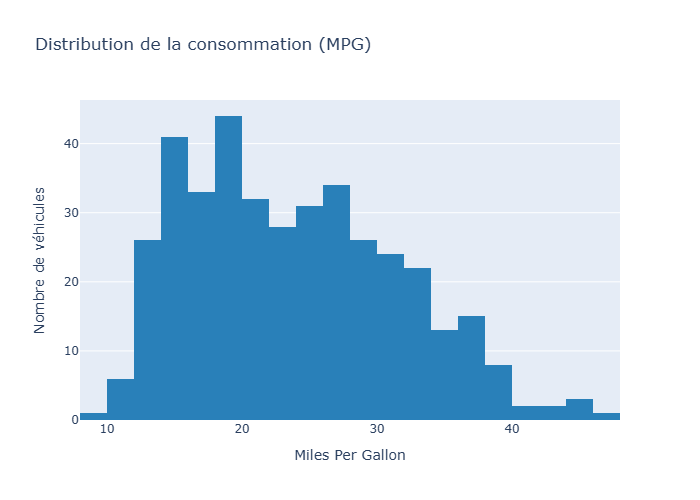

In [8]:
fig = px.histogram(
    mpg_df,
    x='mpg',
    nbins=30,
    title='Distribution de la consommation (MPG)',
    labels={'mpg': 'Miles Per Gallon'},
    color_discrete_sequence=['#2980b9']
)
fig.update_layout(yaxis_title='Nombre de véhicules')
fig.show()

Ce graphique compare la consommation moyenne des véhicules selon leur pays d'origine. Il permet de voir si certaines régions produisent des véhicules plus économiques que d'autres. Les véhicules japonais et européens sont significativement plus économiques que les américains. Cela s'explique par leur plus petite taille, leurs moteurs moins puissants et une culture de l'économie de carburant plus développée en Asie et en Europe.

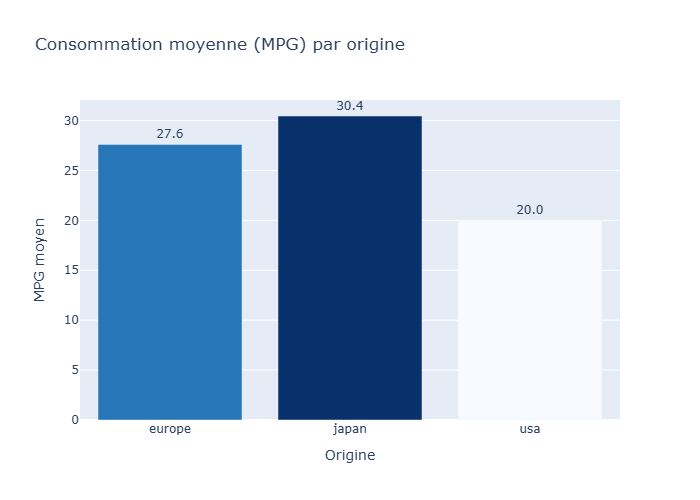

In [9]:
avg_mpg_origin = mpg_df.groupby('origin')['mpg'].mean().round(2).reset_index()
avg_mpg_origin.columns = ['origin', 'avg_mpg']

fig = px.bar(
    avg_mpg_origin,
    x='origin', y='avg_mpg',
    title='Consommation moyenne (MPG) par origine',
    labels={'origin': 'Origine', 'avg_mpg': 'MPG moyen'},
    color='avg_mpg',
    color_continuous_scale='Blues',
    text='avg_mpg'
)
fig.update_traces(texttemplate='%{text:.1f}', textposition='outside')
fig.update_layout(coloraxis_showscale=False)
fig.show()

Ce graphique met en évidence la relation entre le nombre de cylindres et la consommation de carburant. Plus un moteur a de cylindres, plus il est puissant mais aussi plus il consomme. La relation est claire et inversement proportionnelle : plus le nombre de cylindres augmente, plus la consommation (MPG) diminue. Les moteurs à 4 cylindres sont les plus économiques, tandis que les 8 cylindres consomment presque deux fois plus.

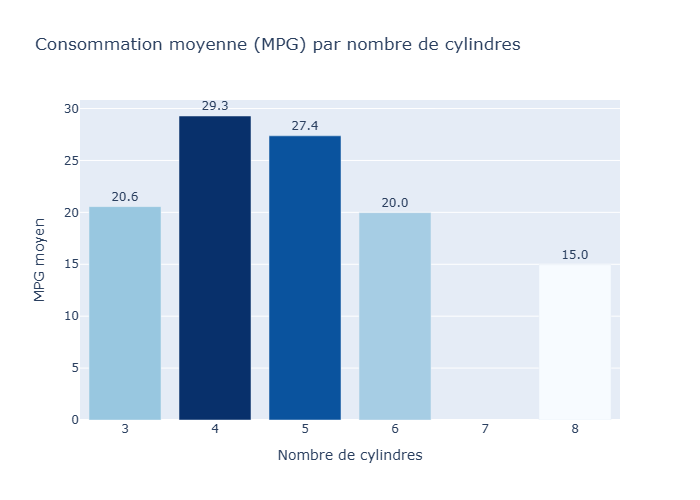

In [10]:
avg_mpg_cyl = mpg_df.groupby('cylinders')['mpg'].mean().round(2).reset_index()
avg_mpg_cyl.columns = ['cylinders', 'avg_mpg']

fig = px.bar(
    avg_mpg_cyl,
    x='cylinders', y='avg_mpg',
    title='Consommation moyenne (MPG) par nombre de cylindres',
    labels={'cylinders': 'Nombre de cylindres', 'avg_mpg': 'MPG moyen'},
    color='avg_mpg',
    color_continuous_scale='Blues',
    text='avg_mpg'
)
fig.update_traces(texttemplate='%{text:.1f}', textposition='outside')
fig.update_layout(coloraxis_showscale=False)
fig.show()

Ce nuage de points explore la relation entre le poids du véhicule et sa consommation. La ligne de tendance permet de quantifier cette relation. Les points sont colorés par origine pour observer si ce pattern est universel ou propre à certaines régions. Il existe une forte corrélation négative entre le poids et le MPG : plus un véhicule est lourd, moins il est économique. Les véhicules américains sont en général plus lourds et moins économiques, tandis que les japonais sont plus légers et plus efficients.

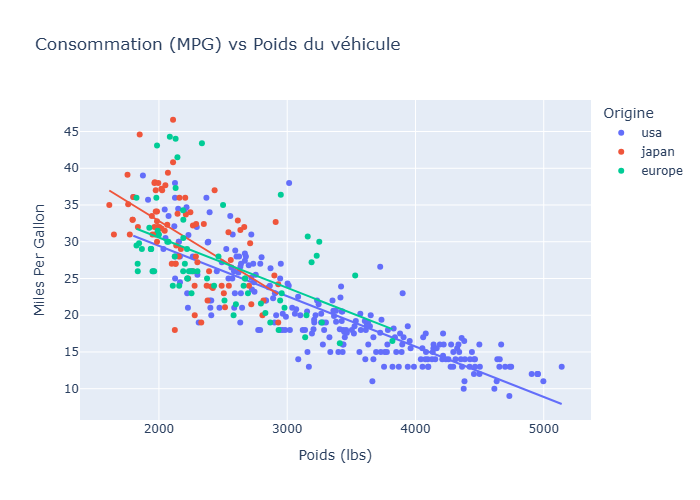

In [14]:
fig = px.scatter(
    mpg_df,
    x='weight', y='mpg',
    color='origin',
    title='Consommation (MPG) vs Poids du véhicule',
    labels={'weight': 'Poids (lbs)', 'mpg': 'Miles Per Gallon', 'origin': 'Origine'},
    trendline='ols'
)
fig.show()

Ce graphique analyse la relation entre la puissance du moteur et la consommation. Les points sont colorés par nombre de cylindres pour observer si la puissance et le nombre de cylindres ont des effets combinés sur le MPG. La puissance et le MPG sont également inversement corrélés. Les moteurs les plus puissants (>150 HP) consomment nettement plus. On observe aussi que les moteurs à 8 cylindres sont systématiquement les plus puissants et les moins économiques.

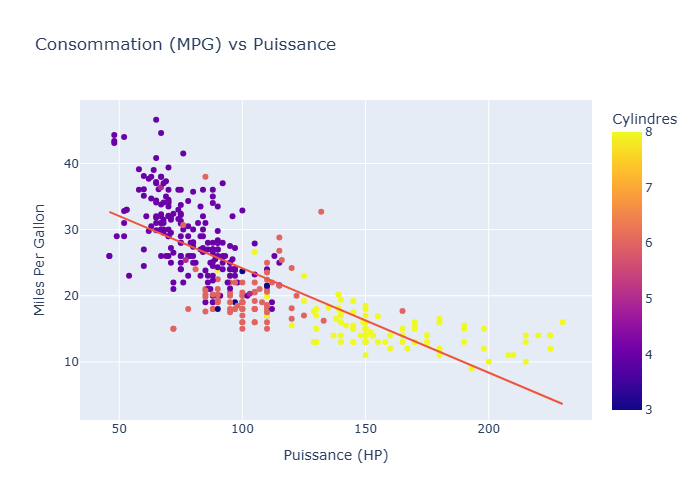

In [15]:
fig = px.scatter(
    mpg_df,
    x='horsepower', y='mpg',
    color='cylinders',
    title='Consommation (MPG) vs Puissance',
    labels={'horsepower': 'Puissance (HP)', 'mpg': 'Miles Per Gallon', 'cylinders': 'Cylindres'},
    trendline='ols'
)
fig.show()

Ce graphique en ligne montre l'évolution temporelle de la consommation moyenne des véhicules. Il permet d'observer l'impact des crises pétrolières et des réglementations environnementales sur l'efficacité des véhicules au fil du temps. On observe une nette amélioration de l'efficacité énergétique à partir de 1975, période qui correspond au choc pétrolier de 1973. Les constructeurs ont été contraints de produire des véhicules plus économiques, ce qui se traduit par une hausse continue du MPG moyen jusqu'en 1982.

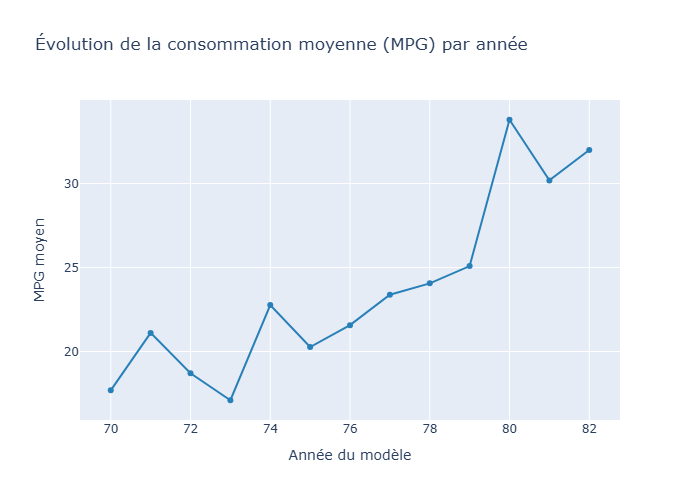

In [16]:
avg_mpg_year = mpg_df.groupby('model_year')['mpg'].mean().round(2).reset_index()
avg_mpg_year.columns = ['model_year', 'avg_mpg']

fig = px.line(
    avg_mpg_year,
    x='model_year', y='avg_mpg',
    title='Évolution de la consommation moyenne (MPG) par année',
    labels={'model_year': 'Année du modèle', 'avg_mpg': 'MPG moyen'},
    markers=True,
    color_discrete_sequence=['#2980b9']
)
fig.show()

Ce boxplot compare la distribution du poids des véhicules selon leur origine. Il permet de visualiser non seulement la moyenne, mais aussi la dispersion et les valeurs extrêmes pour chaque région. Les véhicules américains sont beaucoup plus lourds (médiane ~3500 lbs) et présentent une plus grande variabilité. Les véhicules japonais sont les plus légers et les plus homogènes en termes de poids, ce qui explique leur meilleure efficacité énergétique.

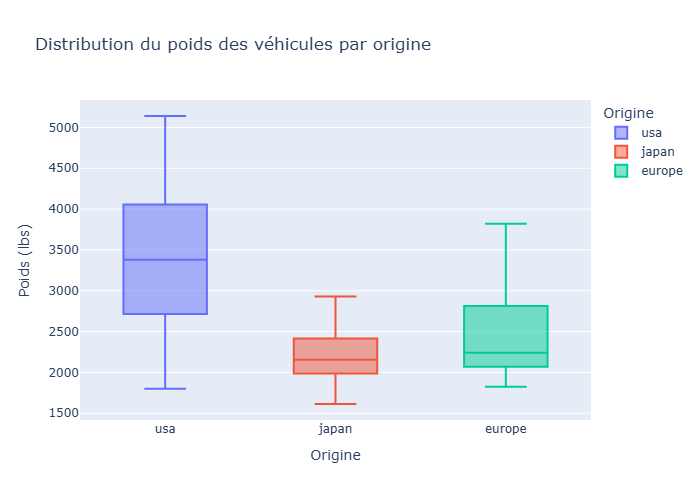

In [17]:
fig = px.box(
    mpg_df,
    x='origin', y='weight',
    color='origin',
    title='Distribution du poids des véhicules par origine',
    labels={'origin': 'Origine', 'weight': 'Poids (lbs)'}
)
fig.show()

Ce boxplot analyse comment l'accélération varie selon le nombre de cylindres. Contrairement à ce qu'on pourrait intuitivement penser, un plus grand nombre de cylindres ne signifie pas forcément une meilleure accélération au sens statistique du terme utilisé ici (temps pour atteindre 60 mph — une valeur plus haute signifie une accélération plus lente). Les moteurs à 4 cylindres ont paradoxalement des valeurs d'accélération plus élevées (plus lents à accélérer), tandis que les 8 cylindres accélèrent plus rapidement (valeur plus basse). Cela confirme que les gros moteurs américains sont conçus pour la performance, au détriment de l'économie de carburant.

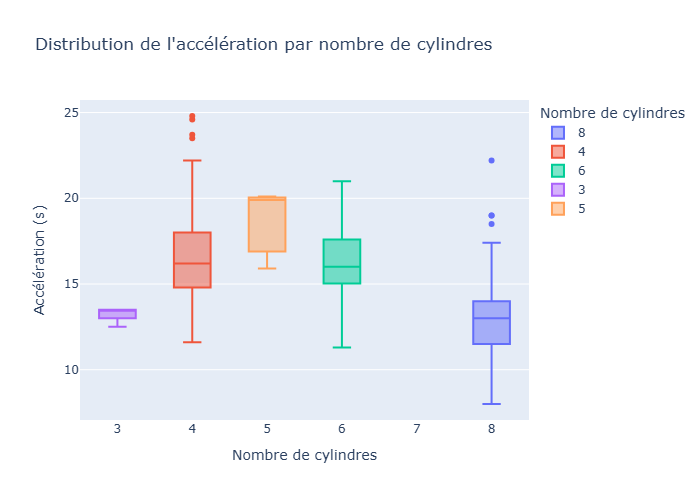

In [18]:
fig = px.box(
    mpg_df,
    x='cylinders', y='acceleration',
    color='cylinders',
    title="Distribution de l'accélération par nombre de cylindres",
    labels={'cylinders': 'Nombre de cylindres', 'acceleration': 'Accélération (s)'}
)
fig.show()

Ce code calcule et affiche une matrice de corrélation interactive sous forme de heatmap. La matrice de corrélation mesure la relation linéaire entre chaque paire de variables numériques du dataset. Les valeurs vont de -1 (corrélation négative forte) à 1 (corrélation positive forte), 0 signifiant aucune relation. Cela permet d'identifier rapidement quelles variables influencent le plus la consommation (MPG).

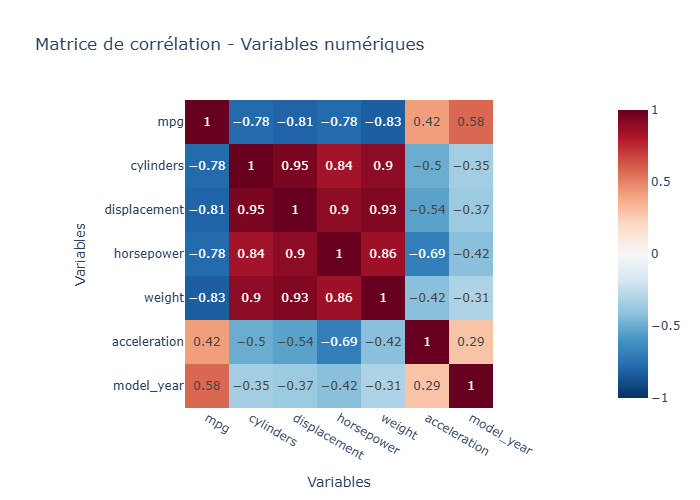

In [20]:
import plotly.figure_factory as ff
import numpy as np

# Sélection de toutes les variables numériques
continuous_vars = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year']

# Calcul de la matrice de corrélation
corr_matrix = mpg_df[continuous_vars].corr().round(2)

# Création de la heatmap
fig = px.imshow(
    corr_matrix,
    title='Matrice de corrélation - Variables numériques',
    color_continuous_scale='RdBu_r',
    zmin=-1, zmax=1,
    text_auto=True
)
fig.update_layout(
    xaxis_title='Variables',
    yaxis_title='Variables'
)
fig.show()